# 🐾 Animal Image Classification System

## 📌 Overview

The Animal Image Classification System is a Deep Learning project that classifies animal images into one of 10 predefined animal categories.

The system takes an image as input and uses a trained computer vision model to identify the animal and provide a confidence score for the prediction.

Example:

```text
Input:
dog.jpg

Output:
Prediction: Dog
Confidence: 97.4%

In [4]:
import os

dataset_path = "raw-img"

for animal in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, animal)
    
    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)
        print(f"{animal}: {len(images)} images")

cane: 4863 images
cavallo: 2623 images
elefante: 1446 images
farfalla: 2112 images
gallina: 3098 images
gatto: 1668 images
mucca: 1866 images
pecora: 1820 images
ragno: 4821 images
scoiattolo: 1862 images


In [8]:
import numpy as np
import torch
import torchvision

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("MPS available:", torch.backends.mps.is_available())

NumPy: 2.0.2
PyTorch: 2.2.2
Torchvision: 0.17.2
MPS available: True


In [ ]:
import sys
print(sys.executable)

/Users/waleedkhokhar/Documents/DG Skills AI Python /.venv/bin/python


In [11]:
import sys
!{sys.executable} -m pip install "numpy==1.26.4" --force-reinstall

zsh:1: no such file or directory: /Users/waleedkhokhar/Documents/DG


In [6]:
import sys

print(sys.executable)
print(sys.version)

/Users/waleedkhokhar/Documents/DG Skills AI Python /.venv/bin/python
3.9.6 (default, May  7 2023, 23:32:45) 
[Clang 14.0.3 (clang-1403.0.22.14.1)]


In [12]:
import sys
!"/Users/waleedkhokhar/Documents/DG Skills AI Python/.venv/bin/python" -m pip install "numpy==1.26.4" --force-reinstall

zsh:1: no such file or directory: /Users/waleedkhokhar/Documents/DG Skills AI Python/.venv/bin/python


In [13]:
import numpy as np
print("NumPy:", np.__version__)

NumPy: 2.0.2


In [14]:
import torch
import torchvision
import numpy as np
import os

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", np.__version__)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.2.2
Torchvision: 0.17.2
NumPy: 2.0.2
Device: mps


# 1. Import Libraries

In this project, we use PyTorch and Torchvision to build and train
a deep learning image classification model.

We also use NumPy and Matplotlib for numerical operations and
visualizing images from the dataset.

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision

from torchvision import datasets, transforms

print("Libraries imported successfully!")
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", torch.device("mps" if torch.backends.mps.is_available() else "cpu"))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/waleedkhokhar/Documents/DG Skills AI Python /.venv/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_in

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [16]:

%pip install "numpy==1.26.4" --force-reinstall

  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
You should consider upgrading via the '/Users/waleedkhokhar/Documents/DG Skills AI Python /.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np

print("NumPy:", np.__version__)

NumPy: 1.26.4


# 2. Dataset Setup

We are using the Animals-10 dataset containing 10 animal classes.

Each animal class is stored inside its own folder. The folder name
represents the class label of every image inside that folder.

The original dataset uses Italian class names, so we will map them
to English names for our model.

Our goal is to train a multi-class image classification model that
can distinguish between these 10 animal categories.

In [2]:
import os

# Path to our dataset
DATASET_PATH = "raw-img"

# Italian folder name → English animal name
class_mapping = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

print("Dataset path:", DATASET_PATH)
print("Number of classes:", len(class_mapping))
print("\nClasses:")

for folder, animal in class_mapping.items():
    print(f"{folder:12} → {animal}")

Dataset path: raw-img
Number of classes: 10

Classes:
cane         → dog
cavallo      → horse
elefante     → elephant
farfalla     → butterfly
gallina      → chicken
gatto        → cat
mucca        → cow
pecora       → sheep
ragno        → spider
scoiattolo   → squirrel


# 3. Dataset Verification

Before training the model, we verify the dataset by counting the
images inside every animal class.

This helps us understand the dataset size and identify class
imbalance before creating the training pipeline.

In [3]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for folder, animal in class_mapping.items():
    folder_path = os.path.join(DATASET_PATH, folder)

    count = sum(
        1
        for file in os.listdir(folder_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[animal] = count

print("Dataset Distribution:\n")

for animal, count in class_counts.items():
    print(f"{animal:12} : {count}")

print("\nTotal images:", sum(class_counts.values()))

Dataset Distribution:

dog          : 4863
horse        : 2623
elephant     : 1446
butterfly    : 2112
chicken      : 3098
cat          : 1668
cow          : 1866
sheep        : 1820
spider       : 4821
squirrel     : 1862

Total images: 26179


# 4. Dataset Visualization

Before preprocessing and training, we inspect sample images from
each animal class.

This helps us understand the visual characteristics of the dataset
and identify possible problems such as incorrect labels, unusual
images, poor quality, or large variations in image appearance.

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

print("Matplotlib loaded successfully!")

Matplotlib loaded successfully!


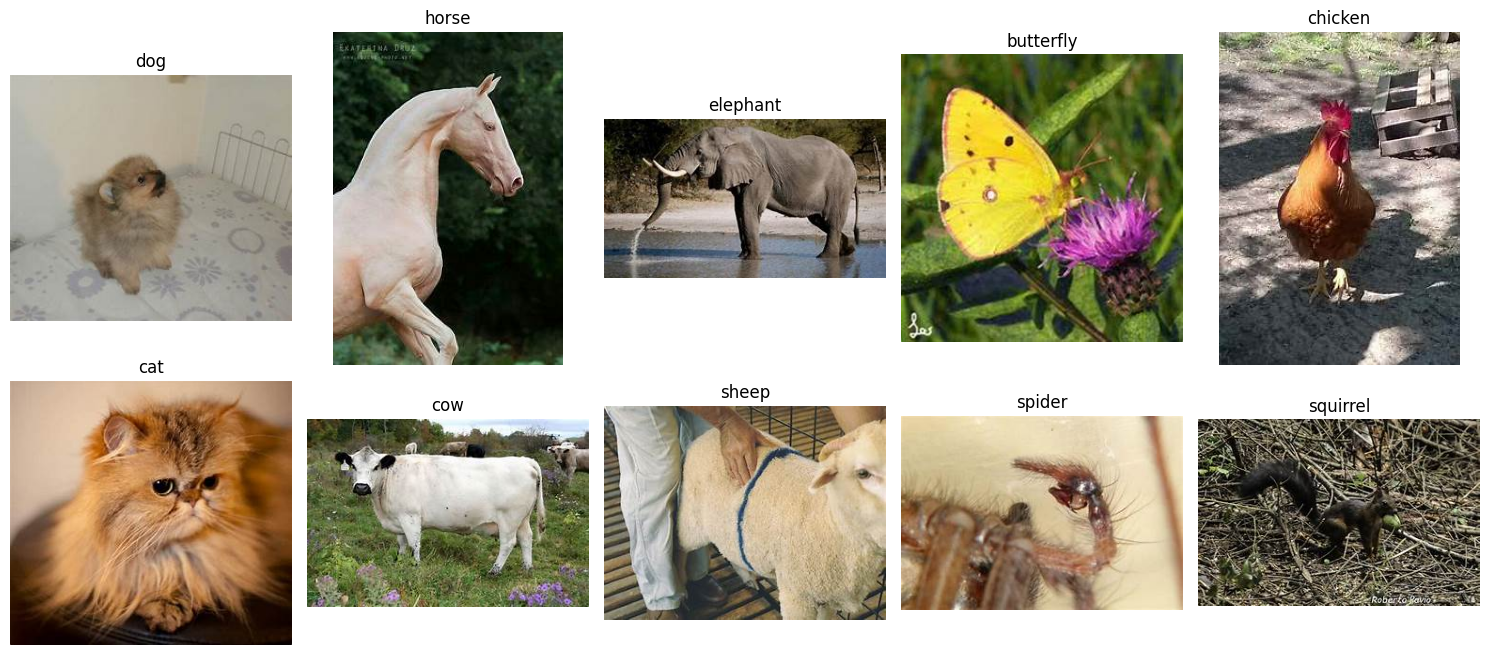

In [6]:
from PIL import Image
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for ax, (folder, animal) in zip(axes.flat, class_mapping.items()):
    folder_path = os.path.join(DATASET_PATH, folder)

    images = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(image_extensions)
    ]

    image_file = random.choice(images)
    image_path = os.path.join(folder_path, image_file)

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(animal)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import os

sample_sizes = []
sample_formats = []

for folder in class_mapping.keys():
    folder_path = os.path.join(DATASET_PATH, folder)

    images = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(image_extensions)
    ]

    # Check 20 random images from each class
    for image_file in random.sample(images, min(20, len(images))):
        image_path = os.path.join(folder_path, image_file)

        try:
            with Image.open(image_path) as img:
                sample_sizes.append(img.size)
                sample_formats.append(img.format)

        except Exception:
            pass

print("Sample images checked:", len(sample_sizes))

print("\nCommon image formats:")
print(set(sample_formats))

print("\nFirst 20 image dimensions:")
print(sample_sizes[:20])

Sample images checked: 200

Common image formats:
{'PNG', 'JPEG'}

First 20 image dimensions:
[(300, 225), (225, 300), (300, 200), (200, 300), (300, 225), (300, 202), (300, 225), (300, 184), (300, 179), (300, 228), (300, 169), (300, 200), (300, 272), (300, 169), (300, 200), (300, 225), (242, 300), (284, 300), (300, 225), (234, 300)]


* checking corecpt fiels 

In [14]:
%pip install scikit-learn

You should consider upgrading via the '/Users/waleedkhokhar/Documents/DG Skills AI Python /.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [11]:
from PIL import Image

corrupted_images = []

for folder in class_mapping.keys():
    folder_path = os.path.join(DATASET_PATH, folder)

    for image_file in os.listdir(folder_path):
        if image_file.lower().endswith(image_extensions):
            image_path = os.path.join(folder_path, image_file)

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception:
                corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for image in corrupted_images[:10]:
        print(image)
else:
    print("All images are valid!")

Corrupted images: 0
All images are valid!


# 5. Train, Validation, and Test Split

We divide the dataset into three separate sets.

- Training data is used to learn the model.
- Validation data is used to monitor and improve the model during training.
- Test data is kept completely separate for the final evaluation.

We use a stratified split so that all 10 animal classes remain
represented proportionally across the three datasets.

In [13]:
import sklearn
print("Scikit-learn:", sklearn.__version__)

Scikit-learn: 1.6.1


In [12]:
from sklearn.model_selection import train_test_split

# Collect every image path and its class label
image_paths = []
labels = []

for folder, animal in class_mapping.items():
    folder_path = os.path.join(DATASET_PATH, folder)

    for image_file in os.listdir(folder_path):
        if image_file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(folder_path, image_file))
            labels.append(animal)

print("Total images:", len(image_paths))

# First split: 70% train, 30% temporary
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Second split: divide temporary 30% into 15% validation and 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("\nTraining images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))
print("Total:", len(train_paths) + len(val_paths) + len(test_paths))

Total images: 26179

Training images: 18325
Validation images: 3927
Testing images: 3927
Total: 26179


In [15]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print("Image transforms created successfully!")

Image transforms created successfully!


# 5. Creating a Custom PyTorch Dataset

After splitting the dataset into training, validation, and testing sets,
we need a way for PyTorch to load our images efficiently during training.

We created a custom `AnimalDataset` class by extending PyTorch's
`Dataset` class.

## What We Did

The custom dataset performs four main tasks:

1. Stores the image paths and their corresponding animal labels.
2. Opens each image when it is requested.
3. Converts every image to RGB format.
4. Applies the appropriate image transformations.
5. Converts animal names into numerical class IDs.

Our model cannot directly understand labels such as `"dog"` or `"cat"`.
Neural networks work with numerical values, so we created a mapping:

dog → 0  
horse → 1  
elephant → 2  
butterfly → 3  
chicken → 4  
cat → 5  
cow → 6  
sheep → 7  
spider → 8  
squirrel → 9

The `class_to_idx` dictionary converts an animal name into its numerical
class ID, while `idx_to_class` allows us to convert the numerical
prediction back into the animal name.

## Technique Used

**PyTorch Dataset**

`Dataset` is a core PyTorch component used to represent and access
training data.

Instead of loading all 26,179 images into memory at once, our dataset
loads images when they are needed. This is much more memory efficient
and works well with PyTorch `DataLoader`.

## Result

We now have a custom dataset structure that can provide:

```text
Image → Transform → Tensor
Label → Numerical Class ID

In [16]:
from torch.utils.data import Dataset
from PIL import Image

# Convert animal names into numerical class IDs
class_names = list(class_mapping.values())

class_to_idx = {
    animal: idx
    for idx, animal in enumerate(class_names)
}

idx_to_class = {
    idx: animal
    for animal, idx in class_to_idx.items()
}


class AnimalDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        
        label = class_to_idx[self.labels[index]]

        if self.transform:
            image = self.transform(image)

        return image, label


print("Classes:", class_names)
print("Class mapping:", class_to_idx)

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Class mapping: {'dog': 0, 'horse': 1, 'elephant': 2, 'butterfly': 3, 'chicken': 4, 'cat': 5, 'cow': 6, 'sheep': 7, 'spider': 8, 'squirrel': 9}


# 6. Creating PyTorch DataLoaders

The `AnimalDataset` knows how to load and transform an individual image,
but during training we do not want to send images to the model one at a
time.

We use PyTorch's `DataLoader` to load images in batches.

## What We Are Doing

We create three datasets:

- Training dataset → uses training images and training augmentation.
- Validation dataset → uses validation images without augmentation.
- Test dataset → uses test images without augmentation.

Then we create a `DataLoader` for each dataset.

Our training batch size will be 32, meaning the model processes
32 images at a time.

## Why Batches?

Instead of:

```text
Image → Model
Image → Model
Image → Model
...




In [17]:
from torch.utils.data import DataLoader

# Create datasets
train_dataset = AnimalDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = AnimalDataset(
    val_paths,
    val_labels,
    transform=val_test_transform
)

test_dataset = AnimalDataset(
    test_paths,
    test_labels,
    transform=val_test_transform
)

# Batch size
BATCH_SIZE = 32

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully!")
print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully!
Batch size: 32
Training batches: 573
Validation batches: 123
Testing batches: 123


# 7. Inspecting a Training Batch

Before building our neural network, we verify that the PyTorch
DataLoader is producing data in the format expected by the model.

We will inspect one batch from the training DataLoader.

The expected image tensor shape is:

```text
(batch_size, channels, height, width)

In [18]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nFirst 10 labels:")
print(labels[:10])

print("\nImage data type:", images.dtype)
print("Label data type:", labels.dtype)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])

First 10 labels:
tensor([5, 1, 8, 2, 5, 1, 0, 0, 8, 4])

Image data type: torch.float32
Label data type: torch.int64


# 8. Building a CNN Baseline

Now we build our first Convolutional Neural Network (CNN) for the
10-class animal classification problem.

The CNN will learn visual patterns directly from the training images.

A CNN typically learns features in stages:

```text
Image
  ↓
Convolution
  ↓
Activation
  ↓
Pooling
  ↓
Convolution
  ↓
Activation
  ↓
Pooling
  ↓
Flatten
  ↓
Fully Connected Layers
  ↓
10 Class Predictions


## CNN Architecture

Our baseline CNN will use three main convolution blocks.

Each block contains:

- `Conv2d` → extracts visual features from the image
- `ReLU` → adds non-linearity so the network can learn complex patterns
- `MaxPool2d` → reduces the spatial size of the feature maps

The feature extraction process will be:

```text
224 × 224 RGB Image
        ↓
Conv Block 1
        ↓
112 × 112 feature maps
        ↓
Conv Block 2
        ↓
56 × 56 feature maps
        ↓
Conv Block 3
        ↓
28 × 28 feature maps
        ↓
Classification Layers
        ↓
10 animal classes

In [19]:
import torch.nn as nn

class AnimalCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = AnimalCNN()

print(model)

AnimalCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [23]:
import torch
import torch.nn as nn

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.2.2
Device: mps


In [24]:

images, labels = next(iter(train_loader))

# Move the batch to our device
images = images.to(device)

# Move the model to our device
model = model.to(device)

# Make predictions
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])


# 9. Setting Up CNN Training

Our CNN architecture is ready, but the model has not learned anything
yet.

Before training, we need three important components:

1. **Loss Function** — measures how wrong the model's predictions are.
2. **Optimizer** — updates the model's weights to reduce the loss.
3. **Device** — runs the training on Apple's MPS GPU when available.

We will use:

- `CrossEntropyLoss` for our 10-class classification problem.
- `Adam` as the optimizer.
- A learning rate of `0.001`.

During training, the model will repeatedly:

```text
Images
   ↓
CNN
   ↓
Predictions
   ↓
Loss
   ↓
Backpropagation
   ↓
Update Weights

In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Learning rate:", 0.001)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning rate: 0.001


# 10. Training the CNN

Now we train our CNN using the training dataset.

For each batch, the model will:

1. Receive a batch of animal images.
2. Generate predictions for the 10 animal classes.
3. Calculate the loss using the correct labels.
4. Perform backpropagation.
5. Update the model's weights using the Adam optimizer.

We will train the model for several epochs.

One **epoch** means the model has processed the entire training
dataset once.

During training, we will track:

- Training loss
- Training accuracy
- Validation loss
- Validation accuracy

The validation set is used to monitor how well the model performs
on images that were not used to update its weights.

## Training Process

```text
Training Images
      ↓
CNN Prediction
      ↓
Calculate Loss
      ↓
Backpropagation
      ↓
Update Weights
      ↓
Validation
      ↓
Repeat for next epoch

In [26]:
EPOCHS = 5

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item()

        # Track accuracy
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch [1/5] Loss: 2.1473 Accuracy: 0.2095
Epoch [2/5] Loss: 1.9944 Accuracy: 0.2805
Epoch [3/5] Loss: 1.8578 Accuracy: 0.3423
Epoch [4/5] Loss: 1.7476 Accuracy: 0.3848
Epoch [5/5] Loss: 1.6839 Accuracy: 0.4058


In [45]:
# ============================================
# TRANSFER LEARNING - DATA PREPARATION
# ============================================

from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image

IMG_SIZE = 224
BATCH_SIZE = 32

# ImageNet normalization used by pretrained ResNet18
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Recreate datasets
train_dataset = AnimalDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = AnimalDataset(
    val_paths,
    val_labels,
    transform=val_test_transform
)

test_dataset = AnimalDataset(
    test_paths,
    test_labels,
    transform=val_test_transform
)


# Recreate DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Transfer learning data preparation complete!")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Transfer learning data preparation complete!
Training batches: 573
Validation batches: 123
Testing batches: 123


In [46]:
# ============================================
# TRANSFER LEARNING - RESNET18 MODEL
# ============================================

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

# Freeze the pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
model.fc = nn.Linear(
    model.fc.in_features,
    len(class_names)
)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Only train the new final layer
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("ResNet18 loaded successfully!")
print("Number of classes:", len(class_names))
print("Trainable parameters:", sum(
    p.numel() for p in model.parameters() if p.requires_grad
))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/waleedkhokhar/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100.0%


ResNet18 loaded successfully!
Number of classes: 10
Trainable parameters: 5130


In [47]:
# ============================================
# FAST TRANSFER LEARNING TRAINING
# ============================================

EPOCHS = 2

best_val_accuracy = 0.0
best_model_state = None

for epoch in range(EPOCHS):

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = val_correct / val_total

    # Save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2%} | "
        f"Validation Accuracy: {val_accuracy:.2%}"
    )

print("\nBest Validation Accuracy:", f"{best_val_accuracy:.2%}")

Epoch [1/2] | Train Loss: 0.6817 | Train Accuracy: 79.77% | Validation Accuracy: 94.55%
Epoch [2/2] | Train Loss: 0.4697 | Train Accuracy: 84.69% | Validation Accuracy: 95.24%

Best Validation Accuracy: 95.24%


In [48]:
# ============================================
# FINAL TEST EVALUATION
# ============================================

# Load the best model we saved during training
model.load_state_dict(best_model_state)
model = model.to(device)

model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 94.27%


In [49]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         dog       0.97      0.94      0.95       729
       horse       0.91      0.93      0.92       394
    elephant       0.94      0.97      0.96       217
   butterfly       0.90      0.99      0.94       317
     chicken       0.95      0.97      0.96       465
         cat       0.95      0.94      0.95       250
         cow       0.88      0.83      0.86       280
       sheep       0.90      0.89      0.90       273
      spider       0.98      0.97      0.97       723
    squirrel       0.98      0.95      0.96       279

    accuracy                           0.94      3927
   macro avg       0.94      0.94      0.94      3927
weighted avg       0.94      0.94      0.94      3927



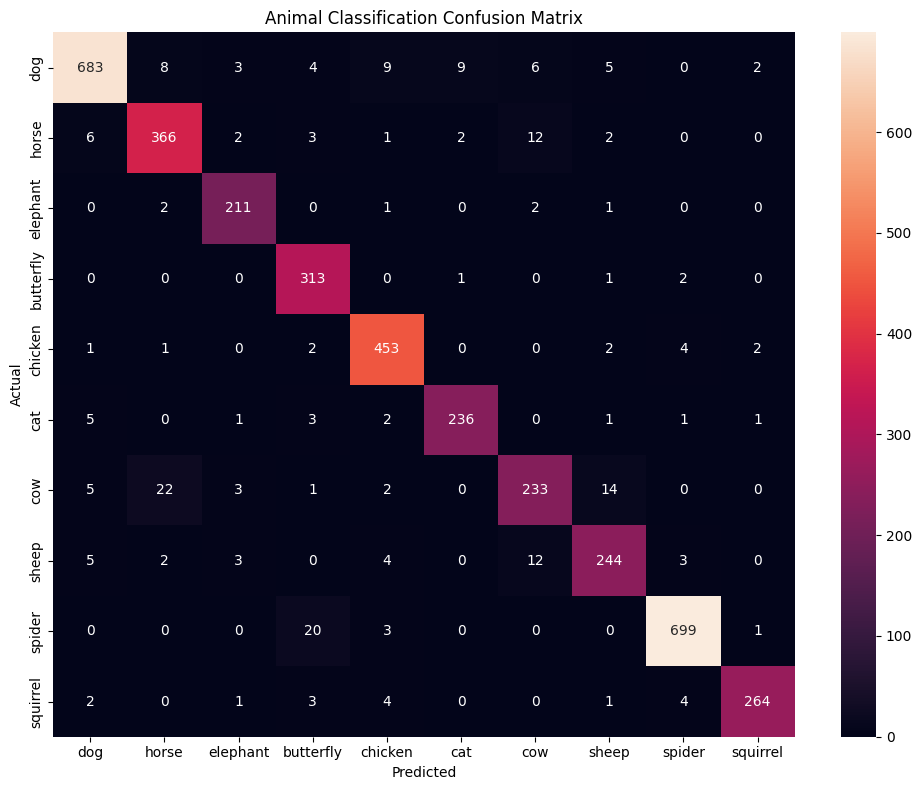

In [50]:
# ============================================
# CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Animal Classification Confusion Matrix")

plt.tight_layout()
plt.show()

# 🐾 Animal Image Classification System

## Project Overview

This project is a Deep Learning based **Animal Image Classification System**.

The main goal of this project was to build a model that can take an animal image as input and classify it into one of 10 predefined animal categories.

The final system follows this general process:

Image
↓
Image Preprocessing
↓
CNN-Based Deep Learning Model
↓
Transfer Learning with ResNet18
↓
Feature Extraction
↓
Classification Layer
↓
Animal Prediction
↓
Confidence Score

The final model is capable of recognizing the following 10 animal classes:

1. Dog
2. Horse
3. Elephant
4. Butterfly
5. Chicken
6. Cat
7. Cow
8. Sheep
9. Spider
10. Squirrel

The project focuses only on the **Deep Learning model**. No frontend, backend, FastAPI, Next.js, or deployment layer was added because the objective was to understand and build the machine learning/deep learning model itself.


# 1. Project Objective

The objective of this project was to move from traditional Machine Learning into practical Deep Learning.

In the previous SMS Spam Detection project, text data was converted into numerical features using TF-IDF and then classified using traditional Machine Learning algorithms such as Logistic Regression and Naive Bayes.

This project is different because the input is an image.

Images contain pixels rather than simple numerical or text features. Therefore, a neural network is required to automatically learn useful visual patterns such as:

- Edges
- Shapes
- Textures
- Colors
- Patterns
- Body structures
- Facial features
- Object parts

The main objective was therefore to build a multi-class image classification model using a CNN architecture and improve its performance using Transfer Learning.


# 2. Dataset

The dataset used in this project is an animal image dataset containing approximately 26,000 images.

The local dataset contains:

- 26,179 total images
- 10 animal classes
- JPEG and PNG images
- Different image dimensions
- Different image aspect ratios

The dataset contains the following classes:

| Class | Number of Images |
|---|---:|
| Dog | 4,863 |
| Horse | 2,623 |
| Elephant | 1,446 |
| Butterfly | 2,112 |
| Chicken | 3,098 |
| Cat | 1,668 |
| Cow | 1,866 |
| Sheep | 1,820 |
| Spider | 4,821 |
| Squirrel | 1,862 |
| **Total** | **26,179** |

The dataset is not perfectly balanced because some classes contain significantly more images than others.

For example, Dog and Spider contain more than 4,800 images, while Elephant contains approximately 1,400 images.

This class imbalance is important because a model can sometimes perform better on classes with more training examples.


# 3. Dataset Folder Structure

The original dataset uses Italian folder names.

The folders were mapped to English animal names using a class mapping dictionary.

The original folders were:

cane
cavallo
elefante
farfalla
gallina
gatto
mucca
pecora
ragno
scoiattolo

They were mapped as follows:

| Original Folder | Final Class |
|---|---|
| cane | dog |
| cavallo | horse |
| elefante | elephant |
| farfalla | butterfly |
| gallina | chicken |
| gatto | cat |
| mucca | cow |
| pecora | sheep |
| ragno | spider |
| scoiattolo | squirrel |

This mapping allowed the model predictions to use readable English class names.


# 4. Dataset Verification

Before training the model, the dataset was inspected carefully.

The purpose of this step was to make sure that the data was usable before spending computational time on model training.

The following checks were performed:

- Dataset folders were verified.
- Number of classes was verified.
- Number of images in every class was counted.
- Total number of images was calculated.
- Random images from every class were visually inspected.
- Image dimensions were inspected.
- Image formats were inspected.
- Corrupted images were checked.


# 5. Visual Inspection

Random images from each animal class were displayed and inspected.

This was important because simply having image files does not guarantee that the dataset is correct.

Visual inspection confirmed that the images actually represented the expected animal classes.

For example:

Dog → dog images

Cat → cat images

Horse → horse images

Elephant → elephant images

and so on.

This helped verify that the dataset structure and class mapping were correct before training.


# 6. Image Dimensions and Formats

The dataset contains images with different dimensions.

Examples included:

300 × 225
225 × 300
300 × 200
300 × 300

This means that the dataset does not have a single standardized image size.

Deep Learning models require batches of images with the same dimensions.

Therefore, the images needed to be transformed into a standard size before being passed to the neural network.

The final model uses:

224 × 224 pixels

This is also the standard input size commonly used with pretrained ImageNet models such as ResNet18.


# 7. Corrupted Image Detection

Every image in the dataset was checked to make sure it could be opened successfully.

The result was:

Corrupted Images: 0

This means that all 26,179 images passed the validation check.

This step is important because corrupted files can cause training to stop unexpectedly during a DataLoader iteration.


# 8. Train, Validation, and Test Split

The complete dataset was divided into three separate sets.

The split used was:

- 70% Training
- 15% Validation
- 15% Testing

The actual number of images was:

| Dataset | Images |
|---|---:|
| Training | 18,325 |
| Validation | 3,927 |
| Testing | 3,927 |
| **Total** | **26,179** |

The split was performed using stratification.

Stratification ensures that the class distribution remains approximately similar across the training, validation, and test datasets.

This is important because the original dataset is not perfectly balanced.


# 9. Why We Need Three Datasets

## Training Set

The training dataset is used to teach the model.

The model sees these images and updates its learnable parameters based on the prediction errors.

## Validation Set

The validation dataset is used during model development.

It helps us determine how well the model performs on images that were not used for updating the model parameters.

Validation performance can help us identify problems such as overfitting.

## Test Set

The test dataset is used for the final evaluation.

These images are kept separate from training.

The final test accuracy gives us a better estimate of how well the trained model generalizes to completely unseen images.


# 10. Image Preprocessing

The images were transformed before being passed to ResNet18.

For training images, the following transformations were used:

- Resize
- Random Resized Crop
- Random Horizontal Flip
- Random Rotation
- Conversion to Tensor
- ImageNet Normalization

For validation and testing images, deterministic transformations were used:

- Resize
- Center Crop
- Conversion to Tensor
- ImageNet Normalization

Training uses random transformations because they help the model see slightly different versions of images.

This is called **Data Augmentation**.

Data augmentation can improve generalization because the model does not simply memorize one exact version of every training image.


# 11. Why ImageNet Normalization Was Used

The final model uses a pretrained ResNet18 model.

ResNet18 was originally trained on ImageNet.

Therefore, the input images are normalized using the ImageNet mean and standard deviation:

Mean:

[0.485, 0.456, 0.406]

Standard Deviation:

[0.229, 0.224, 0.225]

Using the expected normalization makes the input distribution more compatible with the pretrained network.


# 12. Custom PyTorch Dataset

A custom PyTorch Dataset class was created.

The purpose of the custom Dataset was to:

1. Store image paths.
2. Store their corresponding labels.
3. Open an image when requested.
4. Convert the image to RGB.
5. Convert the animal name into a numerical class index.
6. Apply image transformations.
7. Return the processed image and label.

The model cannot directly understand labels such as:

"dog"

"cat"

"horse"

Therefore, the classes were converted into numerical values.

The final mapping was:

Dog → 0

Horse → 1

Elephant → 2

Butterfly → 3

Chicken → 4

Cat → 5

Cow → 6

Sheep → 7

Spider → 8

Squirrel → 9


# 13. DataLoader

PyTorch DataLoader was used to efficiently provide images to the model in batches.

The batch size used was:

32

Therefore, instead of sending one image at a time to the model, the model processes approximately 32 images at once.

The resulting number of batches was:

Training batches: 573

Validation batches: 123

Testing batches: 123

Batch processing makes training more efficient and is standard practice when working with neural networks.


# 14. CNN Baseline Model

Before using Transfer Learning, a custom CNN model was created as a baseline.

The purpose of the baseline was to understand how a CNN performs when it has to learn visual features from the dataset itself.

The custom CNN contained three convolution blocks.

The architecture was approximately:

Input Image
↓
Conv2D
↓
ReLU
↓
Max Pooling
↓
Conv2D
↓
ReLU
↓
Max Pooling
↓
Conv2D
↓
ReLU
↓
Max Pooling
↓
Adaptive Average Pooling
↓
Flatten
↓
Fully Connected Layer
↓
10 Class Predictions


# 15. Custom CNN Results

The custom CNN was trained for 5 epochs.

The training results were:

| Epoch | Training Loss | Training Accuracy |
|---|---:|---:|
| 1 | 2.1473 | 20.95% |
| 2 | 1.9944 | 28.05% |
| 3 | 1.8578 | 34.23% |
| 4 | 1.7476 | 38.48% |
| 5 | 1.6839 | 40.58% |

The final training accuracy was approximately:

40.58%

The model was learning, but its performance was not strong enough for our final system.

Training was also computationally expensive on the available hardware.

Each epoch took approximately 35 minutes.

Therefore, training the custom CNN for 5 epochs took around 3 hours.

This demonstrated an important practical Deep Learning lesson:

A CNN trained from scratch may require significant computational resources and a large amount of training time.


# 16. Why We Changed the Approach

Instead of continuing to train the custom CNN for many more hours, we changed the strategy.

The better approach for this project was:

**Transfer Learning**

Transfer Learning allows us to use knowledge learned by a neural network from a large existing dataset.

Instead of learning every visual feature from zero, the pretrained model already understands many general image features.

The model can then be adapted to our specific animal classification task.

This provides two major advantages:

1. Much faster training.
2. Much better performance with relatively little training.


# 17. Transfer Learning

For the final model, we used:

**ResNet18**

ResNet18 is a Convolutional Neural Network architecture.

The original ResNet18 model was pretrained on ImageNet.

The pretrained network already contains useful visual feature representations.

These features can include general concepts such as:

- Edges
- Curves
- Textures
- Shapes
- Patterns
- Object structures

Instead of throwing away this knowledge, we reused it for our animal classification task.


# 18. ResNet18

The ResNet18 architecture contains many convolutional layers and uses residual connections.

Residual connections help deep neural networks learn effectively by allowing information and gradients to pass through the network more easily.

For this project, the pretrained ResNet18 model was loaded using Torchvision.

The pretrained weights were downloaded and loaded successfully.


# 19. Freezing the Pretrained Layers

Initially, all pretrained ResNet18 parameters were frozen.

This means:

requires_grad = False

for the existing pretrained parameters.

Therefore, the original ResNet18 feature extractor was not modified during the first transfer-learning training stage.

Only the newly created classification layer was trained.

This greatly reduced the number of trainable parameters.


# 20. Replacing the Final Layer

The original ResNet18 model was designed for ImageNet classification.

ImageNet contains 1000 classes.

Our project only has 10 classes.

Therefore, the original final classification layer was replaced.

The new layer was:

Linear → 10 outputs

Each output corresponds to one animal class.

The model therefore produces 10 numerical scores for every input image.

These scores are then converted into probabilities using Softmax.


# 21. Trainable Parameters

After freezing the pretrained layers and replacing the final classification layer, the number of trainable parameters was:

5,130

This is extremely small compared with training the entire ResNet18 network.

This is one of the reasons the transfer-learning approach was much faster.


# 22. Loss Function

The project uses:

CrossEntropyLoss

This is a standard loss function for multi-class classification.

The model produces a score for each of the 10 animal classes.

CrossEntropyLoss compares those predictions with the correct class and produces a loss value.

During training, the optimizer attempts to minimize this loss.

In simple terms:

Correct prediction → lower loss

Incorrect prediction → higher loss


# 23. Optimizer

The optimizer used was:

Adam

Learning rate:

0.001

The optimizer updates the trainable parameters of the final classification layer based on the gradients calculated during backpropagation.


# 24. Training Process

The final transfer-learning model was trained for only:

2 epochs

This was intentional.

The goal was not to train for many hours unnecessarily.

The pretrained ResNet18 already contained useful visual knowledge.

Therefore, only a small amount of training was required to adapt the final classification layer to our 10 animal classes.


# 25. Transfer Learning Training Results

The training results were:

| Epoch | Train Loss | Train Accuracy | Validation Accuracy |
|---|---:|---:|---:|
| 1 | 0.6817 | 79.77% | 94.55% |
| 2 | 0.4697 | 84.69% | 95.24% |

The best validation accuracy was:

**95.24%**

This was a major improvement compared with the custom CNN baseline.


# 26. CNN vs Transfer Learning

The difference between the two approaches was significant.

### Custom CNN

Training Accuracy after 5 epochs:

40.58%

### Transfer Learning

Validation Accuracy after only 2 epochs:

95.24%

This demonstrates why Transfer Learning is extremely useful in practical Deep Learning projects.

Instead of spending several hours training a CNN from scratch, we reused a pretrained model that had already learned useful visual representations.


# 27. Final Test Evaluation

After training, the best validation model was restored.

The model was then evaluated on the completely unseen test dataset.

The test dataset contained:

3,927 images

The final test accuracy was:

**94.27%**

This is the main final performance metric of the project.

It means that the model correctly classified approximately 94 out of every 100 test images.


# 28. Why Test Accuracy Is Important

We should not judge a model only from training accuracy.

Training accuracy tells us how well the model performs on images used during training.

Validation accuracy tells us how well it performs during model development on unseen validation images.

Test accuracy is used for the final evaluation on a separate dataset.

Our final result was:

Training Accuracy: 84.69%

Best Validation Accuracy: 95.24%

Final Test Accuracy: 94.27%

The small difference between validation and test performance indicates that the model generalizes well to unseen images from the same dataset.


# 29. Classification Report

The final model was evaluated using precision, recall, and F1-score for every animal class.

The results were:

| Animal | Precision | Recall | F1-Score |
|---|---:|---:|---:|
| Dog | 0.97 | 0.94 | 0.95 |
| Horse | 0.91 | 0.93 | 0.92 |
| Elephant | 0.94 | 0.97 | 0.96 |
| Butterfly | 0.90 | 0.99 | 0.94 |
| Chicken | 0.95 | 0.97 | 0.96 |
| Cat | 0.95 | 0.94 | 0.95 |
| Cow | 0.88 | 0.83 | 0.86 |
| Sheep | 0.90 | 0.89 | 0.90 |
| Spider | 0.98 | 0.97 | 0.97 |
| Squirrel | 0.98 | 0.95 | 0.96 |

Overall:

Accuracy: 94.27%

Macro F1-score: approximately 0.94

Weighted F1-score: approximately 0.94


# 30. Class-Level Performance

The model performed particularly well on:

- Spider
- Elephant
- Chicken
- Squirrel
- Dog
- Cat

Spider achieved an F1-score of approximately 0.97.

Elephant, Chicken, and Squirrel achieved approximately 0.96 F1-score.

Dog and Cat achieved approximately 0.95 F1-score.

The weakest class was Cow, with an F1-score of approximately 0.86.

This does not necessarily mean that the model is bad at recognizing cows.

It indicates that cow images were more difficult for the model compared with some of the other classes.


# 31. Confusion Matrix

A confusion matrix was generated to analyze the predictions in more detail.

The confusion matrix contains:

- Actual classes on one axis.
- Predicted classes on the other axis.

The diagonal represents correct predictions.

For example, if an actual Dog image is predicted as Dog, that prediction appears on the Dog/Dog position of the matrix.

Values outside the diagonal represent misclassifications.

This allows us to identify which animal classes the model confuses with each other.

This is more informative than looking at accuracy alone because it helps us understand the model's specific weaknesses.


# 32. Error Analysis

Error analysis is an important part of a real Machine Learning project.

A model with 94.27% accuracy does not mean that every image will be classified correctly.

Some images may be difficult because of:

- Poor image quality
- Unusual camera angles
- Similar animal appearances
- Multiple animals in one image
- Occlusion
- Background similarity
- Unusual poses
- Very small animals
- Cropped images
- Dataset noise

For example, some animal categories can have visually similar shapes or appearances.

The confusion matrix and classification report help identify these difficult categories.


# 33. Model Prediction Concept

The final model receives an image as input.

For example:

my_dog.jpg

The image goes through the same preprocessing pipeline used during testing.

The processed image is then passed through ResNet18.

The model produces 10 output scores.

Softmax converts these scores into probabilities.

The class with the highest probability becomes the predicted class.

For example:

Animal: Dog

Confidence: 97.4%

The confidence value represents the model's predicted probability for the selected class.

It should not be interpreted as a guarantee that the prediction is correct.


# 34. Final Prediction Pipeline

The complete prediction process is:

User Image
↓
Open Image
↓
Convert to RGB
↓
Resize
↓
Center Crop
↓
Convert to Tensor
↓
ImageNet Normalization
↓
Add Batch Dimension
↓
ResNet18
↓
10 Class Scores
↓
Softmax
↓
Highest Probability
↓
Animal Name + Confidence


# 35. Important Deep Learning Concepts Learned

This project provided practical experience with several important Deep Learning concepts.

### CNN

Convolutional Neural Networks are designed to work effectively with image data.

### Convolution

Convolutional layers learn visual features from images.

### Pooling

Pooling reduces spatial dimensions and helps create more compact feature representations.

### Activation Functions

ReLU introduces non-linearity into the neural network.

### Classification

The model predicts one class from 10 possible animal classes.

### Cross Entropy Loss

Used to measure the difference between predicted classes and actual classes.

### Backpropagation

Used to calculate gradients and update trainable parameters.

### Adam Optimizer

Used to update model parameters during training.

### Data Augmentation

Used to create variation in training images and improve generalization.

### Train/Validation/Test Split

Used to separate training, model development, and final evaluation.

### Transfer Learning

Used to reuse knowledge learned by a pretrained neural network.

### Fine-Grained Evaluation

Precision, recall, F1-score, and confusion matrices were used to analyze performance.


# 36. Most Important Practical Lesson

One of the biggest lessons from this project was that building a larger neural network from scratch is not always the best practical approach.

The custom CNN required approximately 3 hours of training and reached only around 40.58% training accuracy after 5 epochs.

The pretrained ResNet18 achieved:

95.24% validation accuracy

and

94.27% test accuracy

after only 2 training epochs.

This demonstrates the practical value of Transfer Learning.

In real-world Machine Learning and Deep Learning projects, pretrained models can save significant time and computational resources while providing strong performance.


# 37. Final Model

The final model used in this project is:

**ResNet18 + Transfer Learning**

Configuration:

- Architecture: ResNet18
- Pretrained: Yes
- Pretrained dataset: ImageNet
- Number of classes: 10
- Input size: 224 × 224
- Batch size: 32
- Optimizer: Adam
- Learning rate: 0.001
- Loss: CrossEntropyLoss
- Training epochs: 2
- Best validation accuracy: 95.24%
- Test accuracy: 94.27%


# 38. Final Result

The final Animal Image Classification System successfully learned to classify images into 10 different animal categories.

The final model achieved:

**94.27% Test Accuracy**

on 3,927 completely unseen test images.

The project therefore successfully demonstrates a practical Deep Learning workflow from raw image data to a trained and evaluated CNN-based classifier.


# 39. Limitations

Although the model achieved strong test performance, it has limitations.

The model is trained only on the 10 animal categories contained in the dataset.

Therefore, it should not be expected to correctly identify every possible animal in the world.

For example, an image of a lion, tiger, bear, rabbit, or giraffe is outside the model's training classes.

The model will still be forced to choose one of its 10 known classes if it is given an unknown animal.

Therefore, the model's confidence should not be interpreted as proof that the image actually belongs to one of the supported classes.

Another limitation is that test accuracy is measured on images from the same overall dataset distribution.

Real-world images may have different:

- Backgrounds
- Lighting
- Camera quality
- Image resolutions
- Animal poses
- Viewing angles
- Occlusions

Therefore, real-world performance can be lower than the reported test accuracy.


# 40. Future Improvements

If more computational resources were available, the model could potentially be improved using:

- Fine-tuning deeper ResNet layers
- Larger pretrained architectures
- Better data augmentation
- Class-balanced sampling
- Learning-rate scheduling
- More training epochs
- Hyperparameter tuning
- More diverse datasets
- Additional animal classes
- Real-world image evaluation

However, these improvements were intentionally not added because the current model already achieved strong performance with significantly less training time.


# 41. Final Project Architecture

The complete model architecture can be summarized as:

Raw Animal Dataset
        ↓
Dataset Verification
        ↓
Train / Validation / Test Split
        ↓
Image Preprocessing
        ↓
Data Augmentation
        ↓
PyTorch Dataset
        ↓
PyTorch DataLoader
        ↓
CNN Baseline
        ↓
Transfer Learning
        ↓
Pretrained ResNet18
        ↓
Freeze Pretrained Layers
        ↓
Replace Final Layer
        ↓
Train Classification Layer
        ↓
Validation
        ↓
Best Model Selection
        ↓
Final Test Evaluation
        ↓
Classification Report
        ↓
Confusion Matrix
        ↓
Final Animal Classifier


# 42. Conclusion

This project successfully demonstrates the complete workflow of a practical Deep Learning image classification system.

We started with raw animal images and first verified the dataset, including class counts, image formats, image dimensions, visual samples, and corrupted files.

The dataset was then divided into training, validation, and testing sets using stratified splitting.

A custom CNN was initially created as a baseline. Although the CNN successfully learned some visual patterns, it required significant training time and achieved only 40.58% training accuracy after five epochs.

Instead of continuing to spend several hours training the CNN from scratch, Transfer Learning was introduced.

A pretrained ResNet18 model was used as the final architecture. The pretrained feature extraction layers were frozen and the final classification layer was replaced with a new layer containing 10 outputs.

After only two training epochs, the model achieved:

Best Validation Accuracy: 95.24%

Final Test Accuracy: 94.27%

The classification report showed strong performance across most animal classes, with the best performance coming from classes such as Spider, Elephant, Chicken, and Squirrel.

The project also demonstrated the importance of evaluating a model beyond simple accuracy through precision, recall, F1-score, and confusion matrix analysis.

Overall, this project provided practical experience with:

- PyTorch
- CNNs
- Image preprocessing
- Data augmentation
- Dataset management
- DataLoaders
- Transfer Learning
- ResNet18
- Model training
- Validation
- Test evaluation
- Classification reports
- Confusion matrices
- Error analysis
- Multi-class image classification

The final result is a strong 10-class animal image classifier based on Deep Learning and Transfer Learning.